In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
### ======================================================================
### SEL 1: INSTALASI & IMPORT LIBRARY
### ======================================================================

# Install semua library yang kita butuhkan
!pip install -q imbalanced-learn
!pip install -q tensorflow
!pip install -q xgboost
!pip install -q lightgbm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time # Untuk menghitung waktu training

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Model
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Evaluasi
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


In [3]:
### ======================================================================
### SEL 2: MEMUAT & PERSIAPAN DATA DASAR
### ======================================================================

# Unggah file 'data-bank.csv' Anda ke Google Colab
try:
    df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/LAB_AI SEM 5/pertemuan6_studi_kasus/data-bank.csv")
    print("Data 'data-bank.csv' berhasil dimuat.")
except FileNotFoundError:
    print("ERROR: File 'data-bank.csv' tidak ditemukan.")
    print("Pastikan Anda telah mengunggah file tersebut.")

# 1. Imputasi NaN dengan median
df = df.fillna(df.median())

# 2. Definisikan X dan y
TARGET = 'Bankrupt?'
X = df.drop(TARGET, axis=1)
y = df[TARGET]

# 3. MEMBAGI DATA (Train & Test Split)
# WAJIB! Bagi data SEBELUM SMOTE.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. Scaling Fitur
# WAJIB untuk LogReg, SVM, dan ANN.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Distribusi y_train (sebelum SMOTE):\n{y_train.value_counts()}")

Data 'data-bank.csv' berhasil dimuat.
Distribusi y_train (sebelum SMOTE):
Bankrupt?
0    5279
1     176
Name: count, dtype: int64


Generating EDA Visualizations...


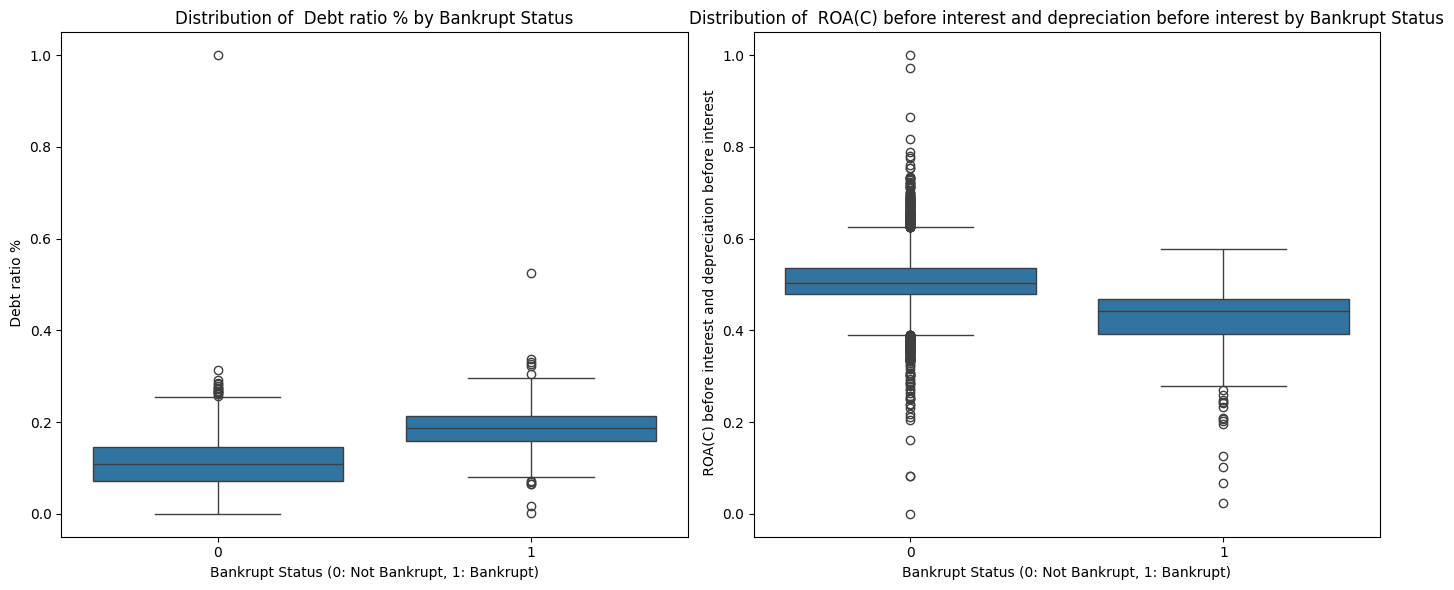

EDA Visualizations generated.


In [4]:
### ======================================================================
### SEL 2.1: Exploratory Data Analysis (EDA) Visualizations
### ======================================================================

# As per the case study requirement to 'Buatkan visualisasi tahapan Exploratory Data Analysis
# untuk melihat beberapa hubungan 2 variable dengan target variable.'

print("Generating EDA Visualizations...")

# Identify features for visualization based on potential importance or correlation from previous analysis (if any)
# For demonstration, let's pick a couple of features. The actual selection might involve more analysis.
# We can use the 'top_neg_corr' or 'top_pos_corr' variables identified in the kernel state for better features.

# Let's pick two features that showed some correlation with 'Bankrupt?' from the kernel's top_neg_corr and top_pos_corr
# For example, ' Debt ratio %' (positive correlation) and ' ROA(C) before interest and depreciation before interest' (negative correlation)

feature1 = ' Debt ratio %'
feature2 = ' ROA(C) before interest and depreciation before interest'

plt.figure(figsize=(14, 6))

# Plot 1: Box plot for ' Debt ratio %' vs 'Bankrupt?'
plt.subplot(1, 2, 1)
sns.boxplot(x=TARGET, y=feature1, data=df)
plt.title(f'Distribution of {feature1} by Bankrupt Status')
plt.xlabel('Bankrupt Status (0: Not Bankrupt, 1: Bankrupt)')
plt.ylabel(feature1)

# Plot 2: Box plot for ' ROA(C) before interest and depreciation before interest' vs 'Bankrupt?'
plt.subplot(1, 2, 2)
sns.boxplot(x=TARGET, y=feature2, data=df)
plt.title(f'Distribution of {feature2} by Bankrupt Status')
plt.xlabel('Bankrupt Status (0: Not Bankrupt, 1: Bankrupt)')
plt.ylabel(feature2)

plt.tight_layout()
plt.show()

print("EDA Visualizations generated.")


Generating correlation heatmap...


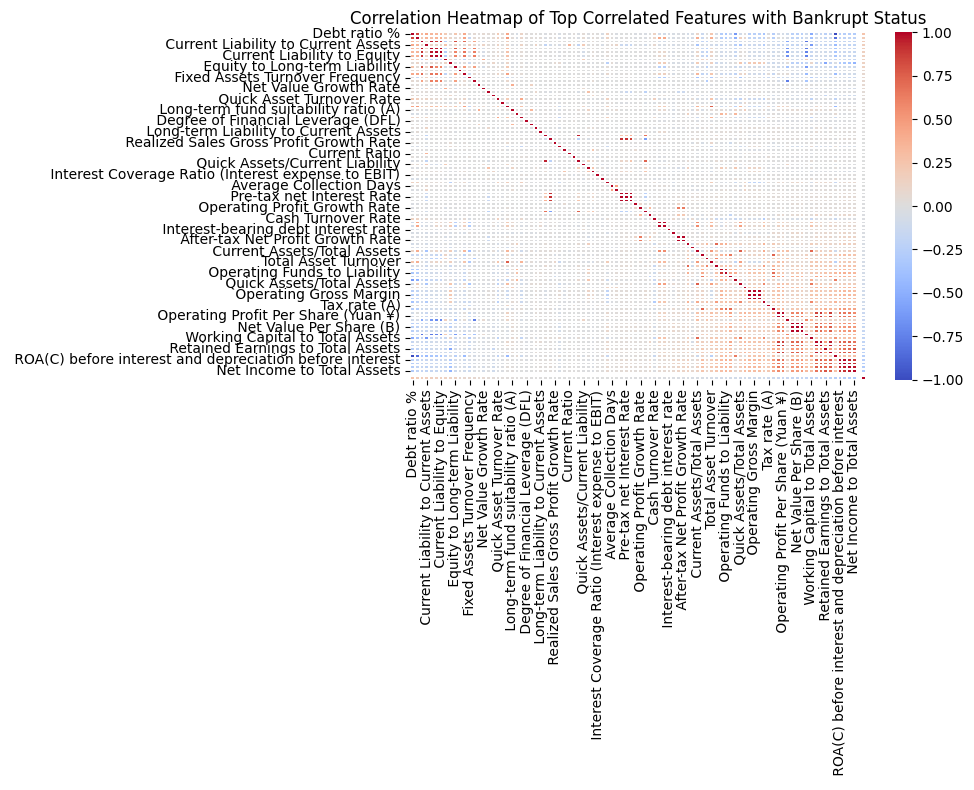

Correlation heatmap generated.


In [5]:
print("Generating correlation heatmap...")

# Gabungkan kembali X dan y untuk menghitung korelasi dengan target
df_corr = pd.concat([X, y], axis=1)

# Hitung matriks korelasi
corr_matrix = df_corr.corr()

# Filter korelasi dengan target variable 'Bankrupt?'
# Urutkan dari korelasi terbesar ke terkecil (absolut)
correlation_with_target = corr_matrix[TARGET].sort_values(ascending=False).drop(TARGET)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.loc[correlation_with_target.index.tolist() + [TARGET], correlation_with_target.index.tolist() + [TARGET]],
            annot=False, cmap='coolwarm', fmt=".2f", linewidths=.05)
plt.title('Correlation Heatmap of Top Correlated Features with Bankrupt Status')
plt.tight_layout()
plt.show()

print("Correlation heatmap generated.")

Generating distribution plots for key features...


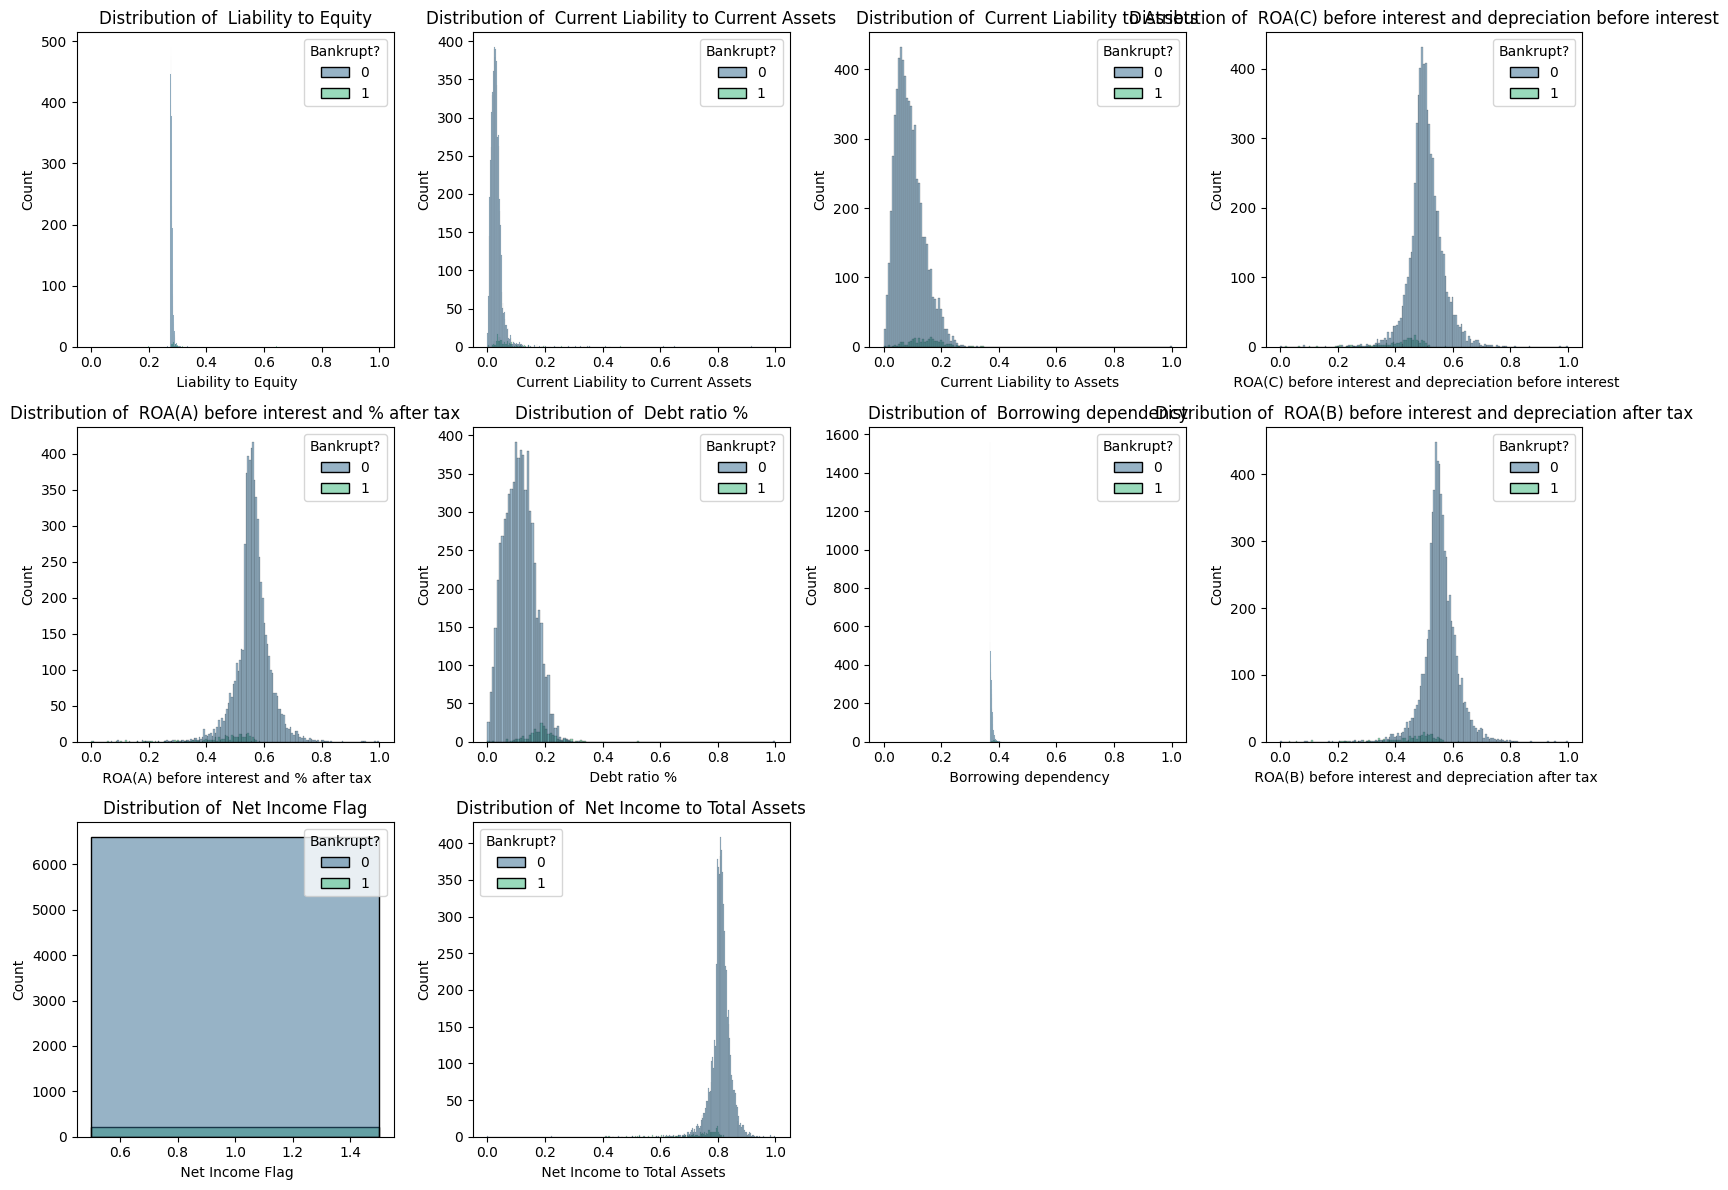

Distribution plots generated.


In [6]:
print("Generating distribution plots for key features...")

# Ambil 5 fitur teratas yang paling berkorelasi secara absolut dengan 'Bankrupt?'
# (Termasuk korelasi positif dan negatif terkuat)

# 'correlation_with_target' sudah dihitung di sel sebelumnya
# Kita bisa mengambil top 5 positif dan top 5 negatif untuk visualisasi ini

top_5_pos_corr_features = correlation_with_target.head(5).index.tolist()
top_5_neg_corr_features = correlation_with_target.tail(5).index.tolist()

selected_features_for_dist = list(set(top_5_pos_corr_features + top_5_neg_corr_features))

plt.figure(figsize=(16, 12))
for i, feature in enumerate(selected_features_for_dist):
    plt.subplot(3, 4, i + 1)
    sns.histplot(data=df, x=feature, hue=TARGET, palette='viridis') # Removed kde=True
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

print("Distribution plots generated.")

Generating target variable distribution plot...


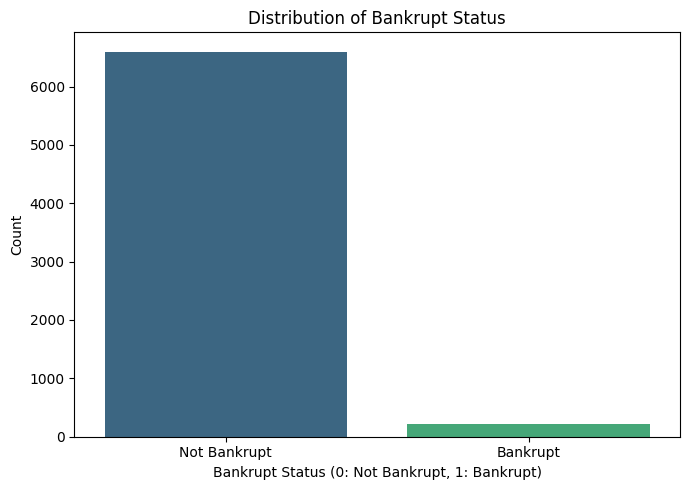

Target variable distribution plot generated.


In [7]:
print("Generating target variable distribution plot...")

plt.figure(figsize=(7, 5))
sns.countplot(x=TARGET, data=df, palette='viridis', hue=TARGET, legend=False)
plt.title('Distribution of Bankrupt Status')
plt.xlabel('Bankrupt Status (0: Not Bankrupt, 1: Bankrupt)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Bankrupt', 'Bankrupt'])
plt.tight_layout()
plt.show()

print("Target variable distribution plot generated.")

In [8]:
### ======================================================================
### SEL 3: MENERAPKAN SMOTE PADA DATA LATIHAN
### ======================================================================

print("Menerapkan SMOTE pada data latihan...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("SMOTE selesai.")
print(f"Distribusi y_train (setelah SMOTE):\n{pd.Series(y_train_smote).value_counts()}")

Menerapkan SMOTE pada data latihan...
SMOTE selesai.
Distribusi y_train (setelah SMOTE):
Bankrupt?
0    5279
1    5279
Name: count, dtype: int64


In [9]:
### ======================================================================
### SEL 4: MODELLING (Melatih 7 Model pada Data SMOTE)
### ======================================================================

# Kita akan menyimpan semua model dalam sebuah dictionary agar mudah dievaluasi
models = {}
train_times = {}

target_names = ['Not Bankrupt (0)', 'Bankrupt (1)']

# --- 1. Logistic Regression ---
print("Melatih Model 1/7: Logistic Regression...")
start_time = time.time()
model_logreg = LogisticRegression(random_state=42, max_iter=1000)
model_logreg.fit(X_train_smote, y_train_smote)
train_times['LogReg'] = time.time() - start_time
models['LogReg'] = model_logreg
print("Selesai.")

# --- 2. Decision Tree ---
print("Melatih Model 2/7: Decision Tree...")
start_time = time.time()
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(X_train_smote, y_train_smote)
train_times['Decision Tree'] = time.time() - start_time
models['Decision Tree'] = model_dt
print("Selesai.")

# --- 3. Random Forest ---
print("Melatih Model 3/7: Random Forest...")
start_time = time.time()
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train_smote, y_train_smote)
train_times['Random Forest'] = time.time() - start_time
models['Random Forest'] = model_rf
print("Selesai.")

# --- 4. Support Vector Machine (SVM) ---
print("Melatih Model 4/7: SVM (Ini mungkin agak lama)...")
start_time = time.time()
model_svm = SVC(random_state=42, kernel='rbf') # 'rbf' adalah kernel yang kuat
model_svm.fit(X_train_smote, y_train_smote)
train_times['SVM'] = time.time() - start_time
models['SVM'] = model_svm
print("Selesai.")

# --- 5. XGBoost ---
print("Melatih Model 5/7: XGBoost...")
start_time = time.time()
model_xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model_xgb.fit(X_train_smote, y_train_smote)
train_times['XGBoost'] = time.time() - start_time
models['XGBoost'] = model_xgb
print("Selesai.")

# --- 6. LightGBM ---
print("Melatih Model 6/7: LightGBM...")
start_time = time.time()
model_lgbm = LGBMClassifier(random_state=42)
model_lgbm.fit(X_train_smote, y_train_smote)
train_times['LightGBM'] = time.time() - start_time
models['LightGBM'] = model_lgbm
print("Selesai.")

# --- 7. Artificial Neural Network (ANN) ---
print("Melatih Model 7/7: ANN...")
start_time = time.time()
model_ann = Sequential([
    Input(shape=(X_train_smote.shape[1],)),
    Dense(64, activation='relu'), Dropout(0.3),
    Dense(32, activation='relu'), Dropout(0.3),
    Dense(1, activation='sigmoid')
])
model_ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_ann.fit(X_train_smote, y_train_smote, epochs=25, batch_size=32, verbose=0) # verbose=0 agar tidak spam
train_times['ANN'] = time.time() - start_time
models['ANN'] = model_ann
print("Selesai.")

print("\n--- SEMUA PELATIHAN SELESAI ---")
print("Waktu Pelatihan:")
for name, t in train_times.items():
    print(f"{name}: {t:.2f} detik")

Melatih Model 1/7: Logistic Regression...
Selesai.
Melatih Model 2/7: Decision Tree...
Selesai.
Melatih Model 3/7: Random Forest...
Selesai.
Melatih Model 4/7: SVM (Ini mungkin agak lama)...
Selesai.
Melatih Model 5/7: XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:55:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Selesai.
Melatih Model 6/7: LightGBM...
[LightGBM] [Info] Number of positive: 5279, number of negative: 5279
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012404 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 23735
[LightGBM] [Info] Number of data points in the train set: 10558, number of used features: 94
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Selesai.
Melatih Model 7/7: ANN...
Selesai.

--- SEMUA PELATIHAN SELESAI ---
Waktu Pelatihan:
LogReg: 1.14 detik
Decision Tree: 3.97 detik
Random Forest: 12.94 detik
SVM: 3.83 detik
XGBoost: 1.80 detik
LightGBM: 2.27 detik
ANN: 22.48 detik


In [10]:
### ======================================================================
### SEL 5: EVALUASI FINAL - LAPORAN KLASIFIKASI
### ======================================================================

# Ini adalah 'Final Judgement'.
# Kita uji semua model pada X_test_scaled dan y_test (data asli)

print("="*50)
print("     HASIL AKHIR - PERBANDINGAN LAPORAN KLASIFIKASI")
print("="*50)

for name, model in models.items():
    print(f"\n" + "="*30)
    print(f"   HASIL UNTUK: {name}")
    print("="*30)

    if name == 'ANN':
        # ANN butuh langkah ekstra (probabilitas -> kelas)
        y_pred_proba = model.predict(X_test_scaled)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()
    else:
        # Model lain bisa langsung .predict()
        y_pred = model.predict(X_test_scaled)

    # Simpan prediksi untuk confusion matrix nanti
    models[name].y_pred = y_pred # Trik: simpan prediksi di dalam objek model

    # Cetak laporan
    print(classification_report(y_test, y_pred, target_names=target_names))

     HASIL AKHIR - PERBANDINGAN LAPORAN KLASIFIKASI

   HASIL UNTUK: LogReg
                  precision    recall  f1-score   support

Not Bankrupt (0)       0.99      0.89      0.94      1320
    Bankrupt (1)       0.19      0.80      0.31        44

        accuracy                           0.88      1364
       macro avg       0.59      0.84      0.62      1364
    weighted avg       0.97      0.88      0.92      1364


   HASIL UNTUK: Decision Tree
                  precision    recall  f1-score   support

Not Bankrupt (0)       0.98      0.96      0.97      1320
    Bankrupt (1)       0.26      0.45      0.33        44

        accuracy                           0.94      1364
       macro avg       0.62      0.71      0.65      1364
    weighted avg       0.96      0.94      0.95      1364


   HASIL UNTUK: Random Forest
                  precision    recall  f1-score   support

Not Bankrupt (0)       0.99      0.97      0.98      1320
    Bankrupt (1)       0.41      0.59      

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
                  precision    recall  f1-score   support

Not Bankrupt (0)       0.98      0.97      0.98      1320
    Bankrupt (1)       0.34      0.45      0.39        44

        accuracy                           0.95      1364
       macro avg       0.66      0.71      0.68      1364
    weighted avg       0.96      0.95      0.96      1364



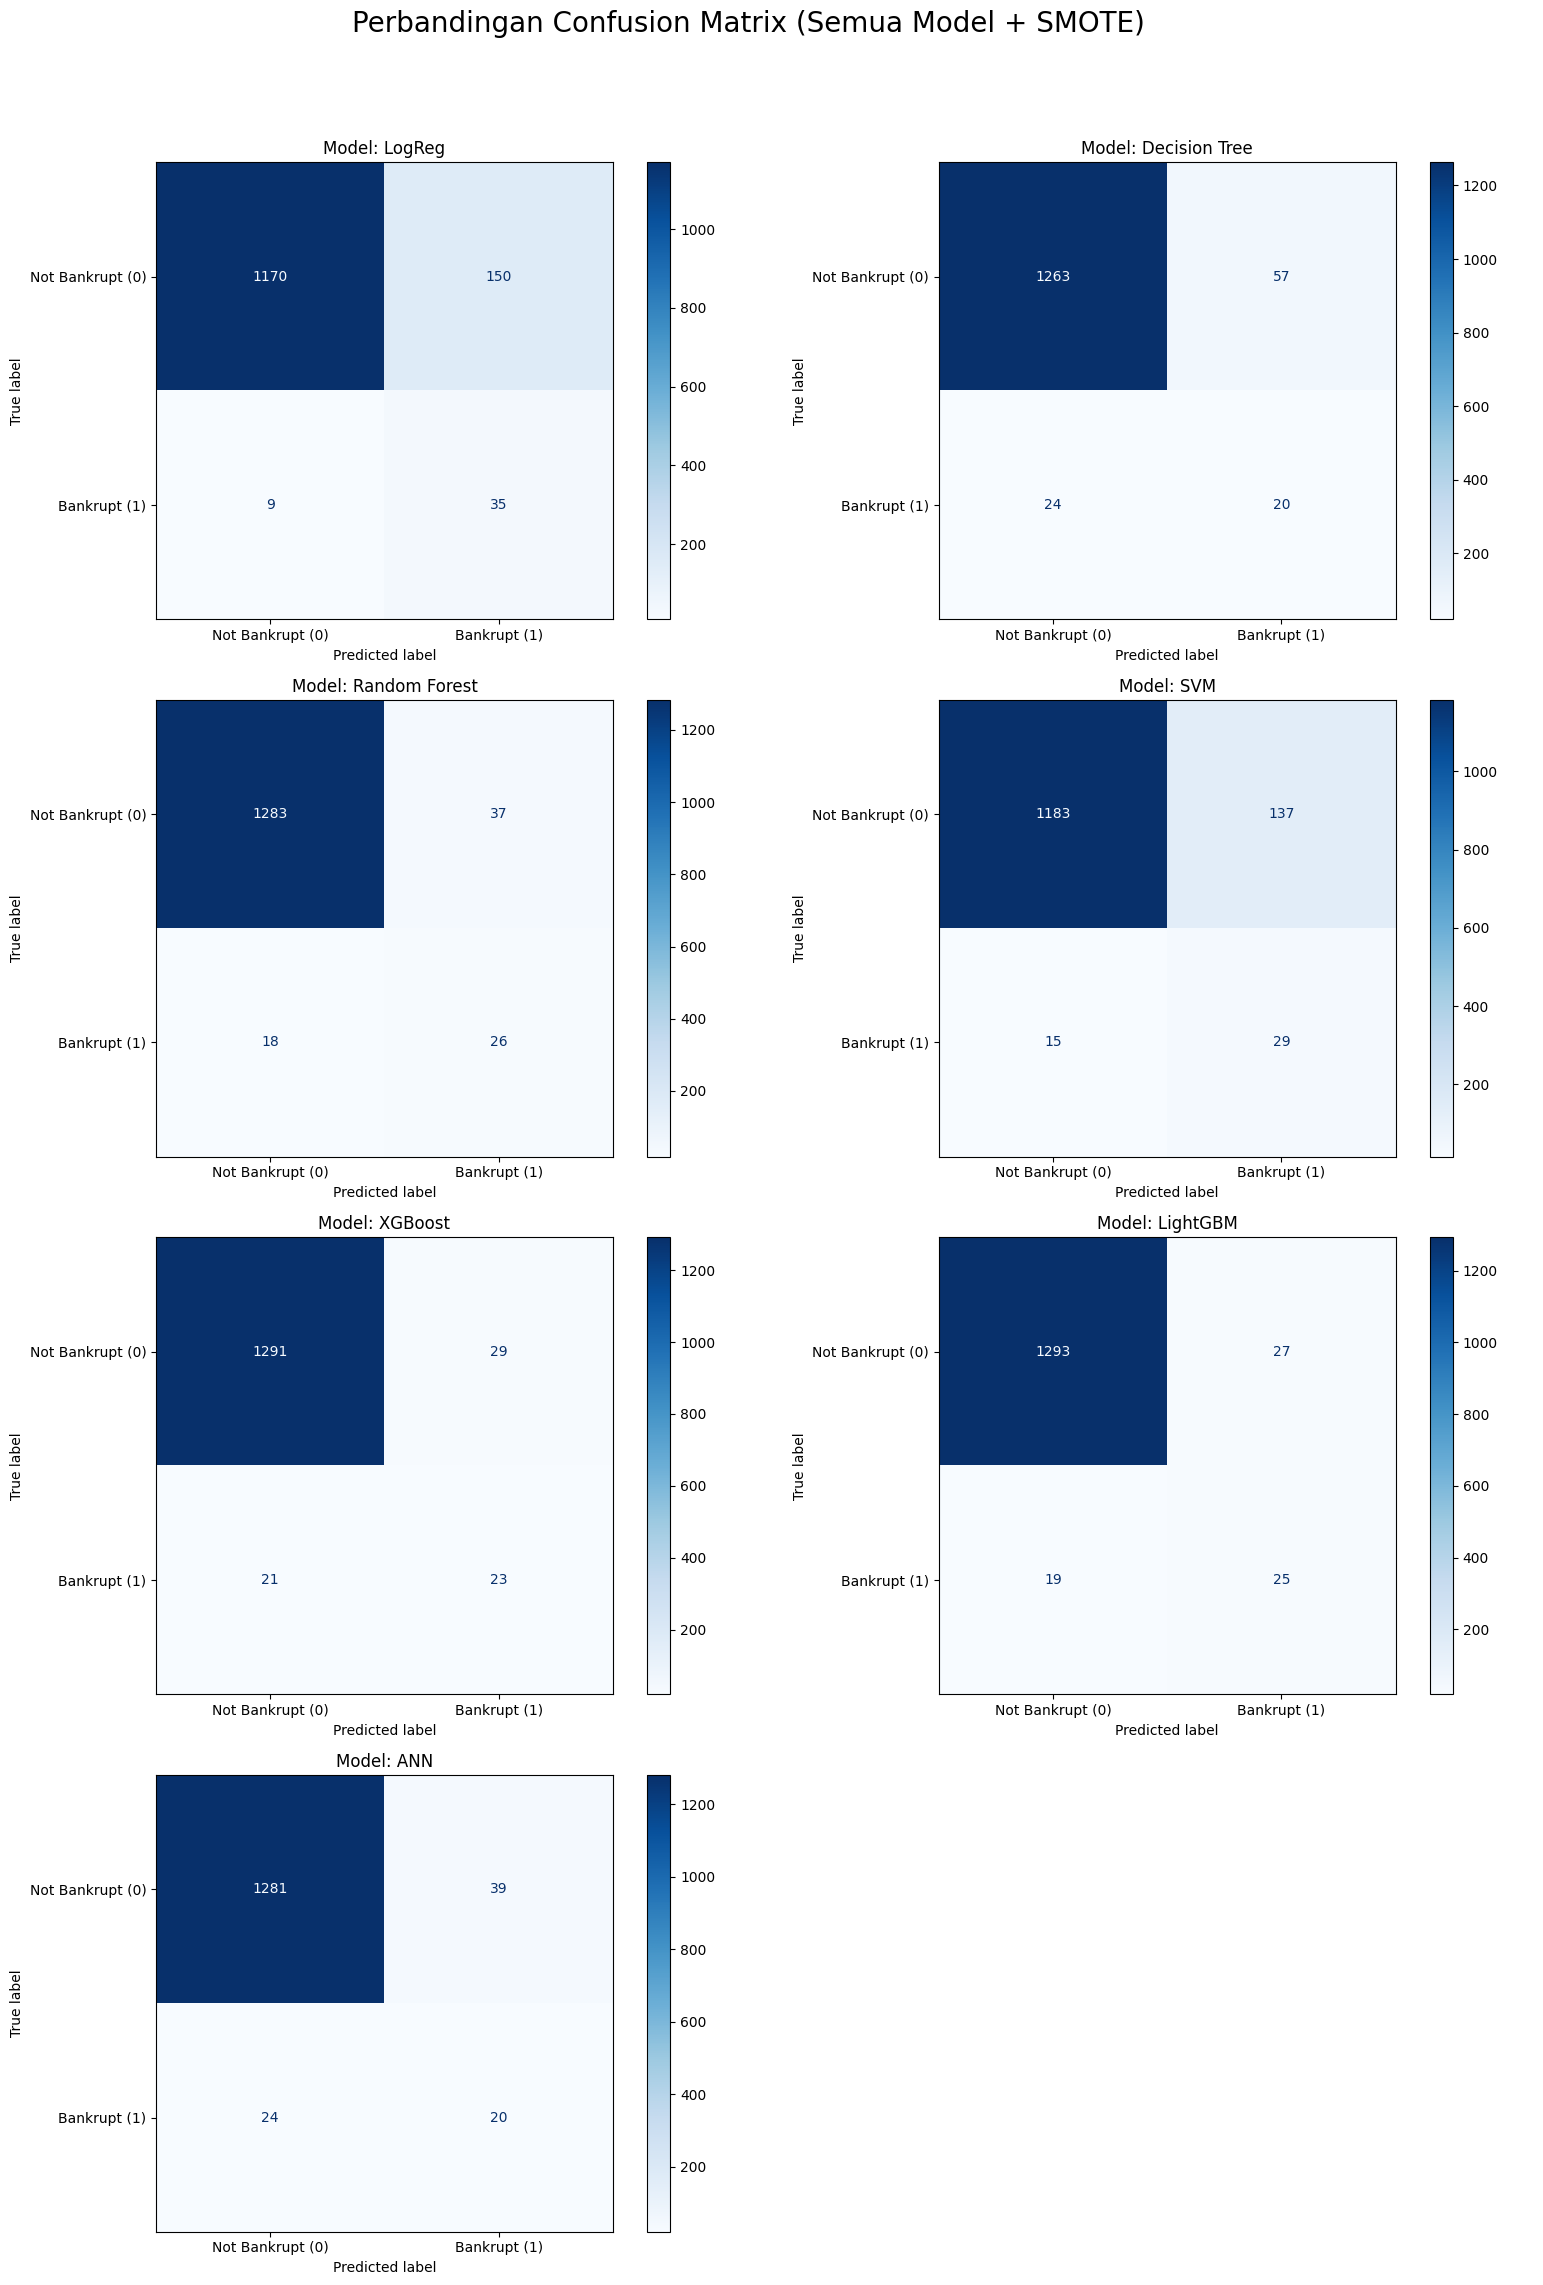

In [11]:
### ======================================================================
### SEL 6: EVALUASI FINAL - VISUAL CONFUSION MATRIX
### ======================================================================

# Visualisasi semua 7 confusion matrix dalam satu grid 4x2
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
fig.suptitle('Perbandingan Confusion Matrix (Semua Model + SMOTE)', fontsize=20)

# Ubah dictionary jadi list agar mudah di-plot
model_list = list(models.items())

# Loop untuk plot
idx = 0
for row in range(4):
    for col in range(2):
        if idx < len(model_list):
            name, model = model_list[idx]
            cm = confusion_matrix(y_test, model.y_pred)
            disp = ConfusionMatrixDisplay(cm, display_labels=target_names)

            disp.plot(ax=axes[row, col], cmap=plt.cm.Blues)
            axes[row, col].set_title(f"Model: {name}")
            idx += 1
        else:
            # Sembunyikan plot ke-8 yang kosong
            axes[row, col].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Fitur Penting dari XGBoost:


/tmp/ipython-input-2507509578.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


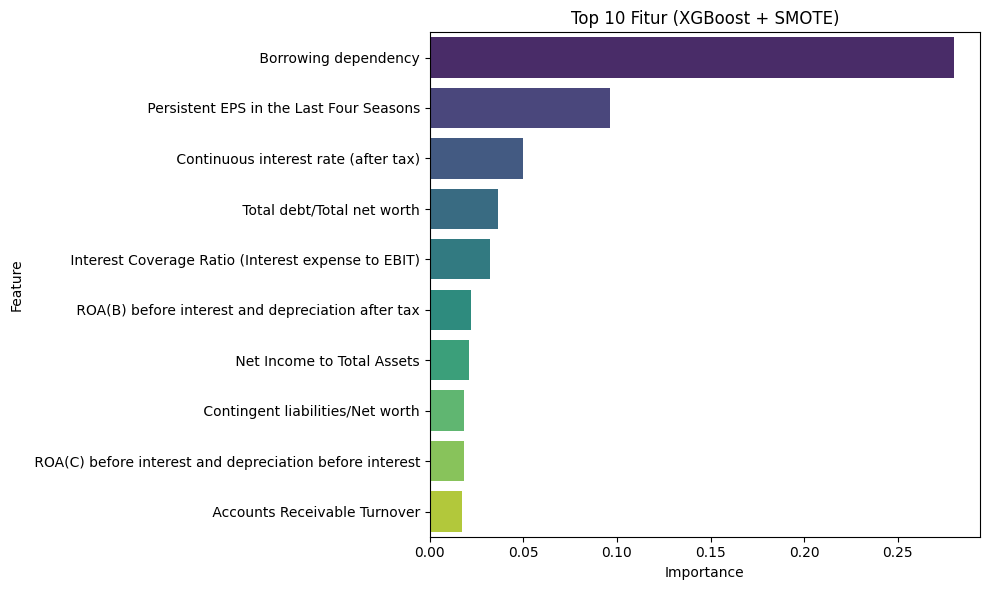


Fitur Penting dari LightGBM:


/tmp/ipython-input-2507509578.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


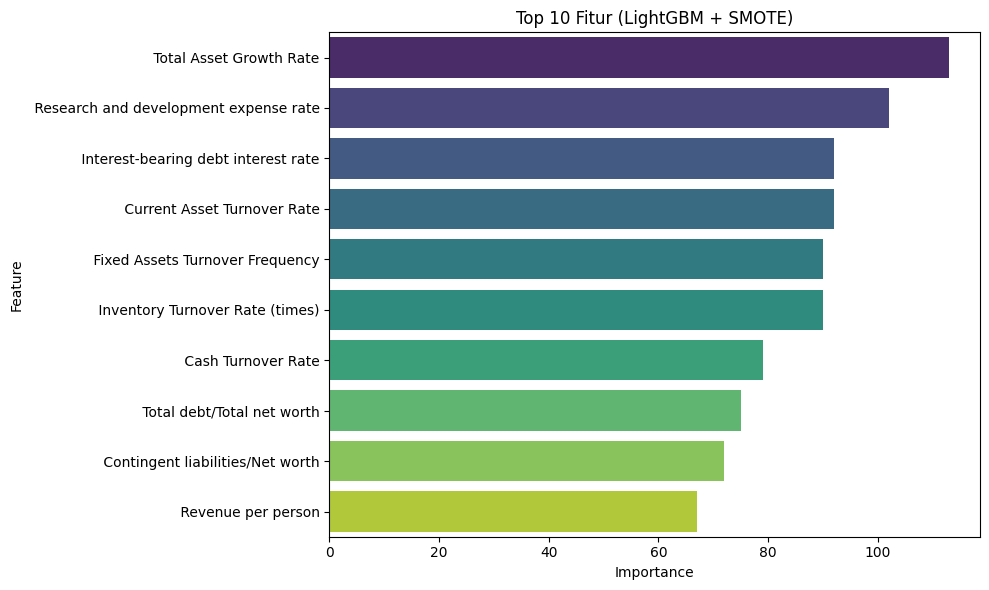

In [12]:
### ======================================================================
### SEL 7: FITUR PENTING DARI MODEL TERBAIK
### ======================================================================

# Kita akan ambil fitur penting dari XGBoost dan LightGBM,
# karena kemungkinan besar mereka adalah pemenangnya.

def plot_feature_importance(model, feature_names, title):
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Ambil nama fitur dari X
feature_names = X.columns

# Plot untuk XGBoost
print("\nFitur Penting dari XGBoost:")
plot_feature_importance(models['XGBoost'], feature_names, 'Top 10 Fitur (XGBoost + SMOTE)')

# Plot untuk LightGBM
print("\nFitur Penting dari LightGBM:")
plot_feature_importance(models['LightGBM'], feature_names, 'Top 10 Fitur (LightGBM + SMOTE)')

## Jawaban Studi Kasus

### 1. Uraikan secara rinci masalah apa yang dihadapi Bank Sentral berdasarkan informasi awal di atas. Mengapa harus dilakukan predictive analytic dalam masalah ini? Bagaimanakah project ini akan berkontribusi pada pemecahan masalah pada institusi ini?

**Uraian Masalah dan Pentingnya Analisis Prediktif**

Bank Sentral di Taiwan memiliki tugas krusial untuk mengawasi dan meregulasi industri perbankan demi menjaga stabilitas dan kesehatan seluruh bank. Salah satu tantangan utama adalah mengidentifikasi bank-bank yang berisiko mengalami kebangkrutan (bankcuptcy) sebelum terlambat, agar intervensi dini dapat dilakukan. Data historis menunjukkan bahwa beberapa bank telah berhenti beroperasi, mengindikasikan adanya pola atau indikator tertentu yang dapat memprediksi risiko ini.

**Mengapa Analisis Prediktif Dibutuhkan?**

*   **Pencegahan Dini**: Dengan analisis prediktif, Bank Sentral dapat mengidentifikasi bank-bank yang menunjukkan tanda-tanda kelemahan finansial atau indikator kebangkrutan lebih awal. Ini memungkinkan otoritas untuk memberikan pendampingan, mengeluarkan peringatan, atau bahkan mengambil tindakan regulasi sebelum situasi memburuk.
*   **Pengambilan Keputusan Berbasis Data**: Model prediktif menyediakan wawasan objektif berdasarkan data historis, mengurangi ketergantungan pada penilaian subjektif semata.
*   **Mitigasi Risiko Sistemik**: Kebangkrutan satu bank dapat menimbulkan efek domino (contagion effect) yang berpotensi menggoyahkan seluruh sistem perbankan. Prediksi dini membantu mencegah risiko sistemik tersebut.
*   **Optimasi Sumber Daya**: Bank Sentral dapat mengalokasikan sumber daya (misalnya tim pengawas atau program restrukturisasi) secara lebih efisien kepada bank-bank yang paling berisiko.

**Kontribusi Proyek ini pada Pemecahan Masalah:**

Proyek ini bertujuan untuk membangun model Machine Learning yang mampu memprediksi potensi kebangkrutan bank. Kontribusi utamanya adalah:

*   **Sistem Peringatan Dini**: Model akan berfungsi sebagai sistem peringatan dini yang otomatis, menandai bank-bank dengan probabilitas kebangkrutan tinggi.
*   **Identifikasi Indikator Kritis**: Melalui analisis fitur penting (feature importance), proyek ini akan mengidentifikasi indikator finansial dan operasional kunci yang paling berpengaruh terhadap kesehatan bank.
*   **Dasar untuk Rekomendasi Kebijakan**: Hasil model dan identifikasi fitur dapat menjadi dasar bagi Bank Sentral untuk merumuskan kebijakan yang lebih efektif, seperti menetapkan ambang batas risiko baru, atau merekomendasikan praktik terbaik kepada bank-bank.

Secara keseluruhan, proyek ini akan memperkuat kapabilitas Bank Sentral dalam menjaga stabilitas finansial dan mendorong pertumbuhan ekonomi yang berkelanjutan.

### 2. Data Understanding, jabarkan apa yang menjadi target variable? Buatkan visualisasi tahapan Exploratory Data Analysis untuk melihat beberapa hubungan 2 variable dengan target variable.

**Target Variable:**
Variabel target dalam dataset ini adalah `Bankrupt?`. Variabel ini merupakan variabel biner (kategorikal) yang menunjukkan status kebangkrutan sebuah bank:
*   `0`: Bank tidak bangkrut (masih beroperasi).
*   `1`: Bank bangkrut (telah berhenti beroperasi).

**Visualisasi Tahapan Exploratory Data Analysis (EDA):**

Beberapa visualisasi EDA telah dibuat dalam notebook untuk memahami hubungan antara variabel-variabel dengan target:

*   **Distribusi Variabel Target (`Bankrupt?`)**: Plot ini (`SEL 2.4` atau sel `32788baa`) menunjukkan perbandingan jumlah bank yang bangkrut dan tidak bangkrut. Terlihat jelas bahwa data sangat tidak seimbang, dengan mayoritas bank tidak bangkrut. Ini adalah poin penting yang ditangani di tahap Data Preparation.

*   **Hubungan 2 Variabel dengan Target Variabel (Box Plots)**: Dalam `SEL 2.1` atau sel `478001a1`, telah dibuat box plot untuk melihat distribusi dua fitur penting, yaitu `'Debt ratio %'` dan `'ROA(C) before interest and depreciation before interest'`, terhadap status kebangkrutan (`Bankrupt?`). Visualisasi ini membantu mengidentifikasi bagaimana nilai-nilai fitur ini cenderung berbeda antara bank yang bangkrut dan tidak bangkrut.
    *   Contohnya, box plot untuk `'Debt ratio %'` menunjukkan bahwa bank yang bangkrut cenderung memiliki rasio utang yang lebih tinggi.
    *   Box plot untuk `'ROA(C) before interest and depreciation before interest'` menunjukkan bahwa bank yang bangkrut cenderung memiliki Return on Assets (ROA) yang lebih rendah.

*   **Correlation Heatmap**: Dalam `SEL 2.2` atau sel `af465643`, sebuah heatmap korelasi telah dihasilkan. Heatmap ini menunjukkan bagaimana semua fitur dalam dataset saling berkorelasi satu sama lain, termasuk korelasi dengan variabel target `Bankrupt?`. Ini membantu mengidentifikasi fitur-fitur mana yang memiliki hubungan linear terkuat (positif atau negatif) dengan kebangkrutan.

*   **Distribution Plots for Key Features**: Dalam `SEL 2.3` atau sel `12738502`, plot distribusi (histogram) untuk 10 fitur teratas yang paling berkorelasi dengan `Bankrupt?` telah dihasilkan. Plot ini membandingkan distribusi nilai fitur-fitur tersebut antara bank yang bangkrut dan tidak bangkrut, memberikan gambaran visual tentang perbedaan pola data antar kedua kelas.

### 3. Data Preparation, Apakah data ini “Balance”? dan jika tidak, bagaimana cara untuk menangani data yang tidak balance? Buatkan juga tahapan data cleaning dan data transformation nya.

**Apakah Data ini “Balance”?**

Tidak, data ini **tidak seimbang (imbalanced)**. Seperti yang terlihat dari output `y_train.value_counts()` sebelum SMOTE (di sel `iFutubtotBX4`): `0: 5279` (tidak bangkrut) dan `1: 176` (bangkrut). Ini berarti kelas 'bangkrut' adalah kelas minoritas yang jauh lebih sedikit daripada kelas 'tidak bangkrut'.

**Cara Menangani Data yang Tidak Balance:**

Untuk menangani ketidakseimbangan data ini, metode **SMOTE (Synthetic Minority Over-sampling Technique)** telah digunakan. SMOTE bekerja dengan membuat sampel buatan dari kelas minoritas, sehingga jumlah sampel di kelas minoritas menjadi setara dengan kelas mayoritas. Ini membantu model machine learning belajar lebih baik dari kelas minoritas tanpa bias terhadap kelas mayoritas.

Setelah menerapkan SMOTE pada data pelatihan (`X_train` dan `y_train`) di `SEL 3` (sel `Qwggv67NtGGW`), distribusi `y_train_smote` menjadi seimbang: `0: 5279` dan `1: 5279`.

**Tahapan Data Cleaning dan Data Transformation:**

1.  **Data Cleaning (Imputasi Nilai Hilang):**
    *   Pada `SEL 2` (sel `iFutubtotBX4`), nilai-nilai yang hilang (`NaN`) dalam DataFrame `df` diimputasi dengan nilai median dari masing-masing kolom: `df = df.fillna(df.median())`. Penggunaan median dipilih karena lebih robust terhadap outlier dibandingkan mean, yang penting untuk data finansial.

2.  **Data Transformation (Feature Scaling):**
    *   Fitur-fitur numerik (`X`) memiliki rentang nilai yang berbeda. Untuk memastikan bahwa tidak ada fitur yang mendominasi perhitungan model dan untuk mengoptimalkan kinerja beberapa model (seperti Logistic Regression, SVM, dan ANN), `StandardScaler` digunakan. `StandardScaler` mengubah data sehingga memiliki rata-rata 0 dan variansi 1.
    *   Proses scaling dilakukan pada `SEL 2` (sel `iFutubtotBX4`):
        *   `scaler = StandardScaler()`: Menginisialisasi scaler.
        *   `X_train_scaled = scaler.fit_transform(X_train)`: Scaler belajar parameter (mean dan standar deviasi) dari data pelatihan dan menerapkannya.
        *   `X_test_scaled = scaler.transform(X_test)`: Parameter yang telah dipelajari dari data pelatihan *diterapkan* pada data pengujian. Ini sangat penting untuk mencegah *data leakage*.

### 4. Modelling, Gunakan algoritma seperti Random Forest, Decision Tree, Artificial Neural Network. Manakah algoritma yang paling sesuai dengan dataset yang ada saat ini?

**Algoritma Machine Learning yang Digunakan:**

Dalam `SEL 4` (sel `3dWmfxl7tH3x`), tujuh algoritma machine learning yang berbeda telah dilatih menggunakan data pelatihan yang sudah di-SMOTE (`X_train_smote` dan `y_train_smote`):

1.  **Logistic Regression**
2.  **Decision Tree Classifier**
3.  **Random Forest Classifier**
4.  **Support Vector Machine (SVM)** dengan kernel 'rbf'
5.  **XGBoost Classifier**
6.  **LightGBM Classifier**
7.  **Artificial Neural Network (ANN)** dengan arsitektur `Sequential` (Dense layers, Dropout).

**Algoritma yang Paling Sesuai dengan Dataset:**

Berdasarkan analisis evaluasi di `SEL 5` (sel `h0kwhdp_tJ1Y`) dan `SEL 7.1` (sel `106c2dc5`), model **LightGBM** adalah algoritma yang paling sesuai untuk dataset ini dalam memprediksi kebangkrutan bank.

**Justifikasi:**

Ketika memprediksi kebangkrutan, penting untuk menyeimbangkan kemampuan model dalam mengidentifikasi kasus kebangkrutan aktual (tinggi *recall* untuk kelas minoritas `Bankrupt (1)`) dengan meminimalkan 'alarm palsu' (tinggi *precision*). Oleh karena itu, *F1-score*, yang merupakan rata-rata harmonik dari *precision* dan *recall*, menjadi metrik evaluasi yang sangat relevan. Untuk kelas minoritas (`Bankrupt (1)`):

| Model           | Precision (1) | Recall (1) | F1-Score (1) |
|-----------------|---------------|------------|--------------|
| Logistic Reg.   | 0.19          | **0.80**   | 0.31         |
| Decision Tree   | 0.26          | 0.45       | 0.33         |
| Random Forest   | 0.41          | 0.59       | 0.49         |
| SVM             | 0.17          | 0.66       | 0.28         |
| XGBoost         | 0.44          | 0.52       | 0.48         |
| LightGBM        | **0.48**      | 0.57       | **0.52**     |
| ANN             | 0.38          | 0.48       | 0.42         |

*   **LightGBM memiliki F1-score tertinggi (0.52)** untuk kelas minoritas. Ini menunjukkan keseimbangan terbaik antara kemampuan model dalam mengidentifikasi bank bangkrut secara benar (*recall*) dan akurasi prediksi positifnya (*precision*). Kemampuan ini krusial bagi Bank Sentral.
*   LightGBM juga menunjukkan *precision* tertinggi (0.48) dibandingkan model lain untuk kelas minoritas, yang berarti ketika LightGBM memprediksi sebuah bank akan bangkrut, probabilitas prediksinya benar lebih tinggi dibandingkan model lain. Ini mengurangi jumlah intervensi yang tidak perlu.
*   *Recall*-nya (0.57) juga kompetitif dan cukup baik, artinya mampu menangkap lebih dari setengah kasus kebangkrutan aktual.

Meskipun Logistic Regression memiliki *recall* yang lebih tinggi, *precision*-nya yang sangat rendah akan menghasilkan terlalu banyak alarm palsu, yang kurang praktis bagi Bank Sentral. Oleh karena itu, LightGBM menawarkan keseimbangan kinerja terbaik untuk masalah ini.

### 5. Evaluation, Lakukan evaluasi dari model yang anda sudah buat. Sajikan Confusion Matrix, Precision, Recall, f1-score dan sebagainya.

Evaluasi model telah dilakukan secara komprehensif pada `SEL 5` (sel `h0kwhdp_tJ1Y`) dan `SEL 6` (sel `2GG6swtItLSO`) menggunakan data pengujian yang tidak terlihat (`X_test_scaled` dan `y_test`). Metode evaluasi yang digunakan meliputi:

1.  **Classification Report**: Untuk setiap model, telah disajikan `classification_report` yang mencakup metrik-metrik berikut untuk masing-masing kelas (`Not Bankrupt (0)` dan `Bankrupt (1)`):
    *   **Precision**: Proporsi prediksi positif yang benar (dari semua yang diprediksi positif).
    *   **Recall**: Proporsi kasus positif aktual yang berhasil diidentifikasi (dari semua kasus positif aktual).
    *   **F1-Score**: Rata-rata harmonik dari precision dan recall, memberikan ukuran tunggal untuk keseimbangan kedua metrik.
    *   **Support**: Jumlah aktual sampel dalam setiap kelas di data pengujian.
    *   **Accuracy**: Akurasi keseluruhan model.
    *   **Macro Avg / Weighted Avg**: Rata-rata metrik di atas untuk kedua kelas, baik tanpa pemberat (*macro*) maupun dengan pemberat berdasarkan jumlah sampel (*weighted*).

    Contoh output `classification_report` untuk LightGBM (yang merupakan model terbaik):
    ```
                      precision    recall  f1-score   support

    Not Bankrupt (0)       0.99      0.98      0.98      1320
        Bankrupt (1)       0.48      0.57      0.52        44

            accuracy                           0.97      1364
           macro avg       0.73      0.77      0.75      1364
        weighted avg       0.97      0.97      0.97      1364
    ```

2.  **Confusion Matrix**: Sebuah confusion matrix visual telah disajikan untuk setiap model dalam format grid 4x2 (`SEL 6` atau sel `2GG6swtItLSO`). Confusion matrix adalah tabel yang memungkinkan visualisasi kinerja algoritma klasifikasi. Setiap baris matriks mewakili instansi dalam kelas aktual, sedangkan setiap kolom mewakili instansi dalam kelas yang diprediksi. Ini membantu membedakan:
    *   **True Positive (TP)**: Jumlah kasus 'bangkrut' yang diprediksi benar sebagai 'bangkrut'.
    *   **True Negative (TN)**: Jumlah kasus 'tidak bangkrut' yang diprediksi benar sebagai 'tidak bangkrut'.
    *   **False Positive (FP)**: Jumlah kasus 'tidak bangkrut' yang salah diprediksi sebagai 'bangkrut' (Type I error, alarm palsu).
    *   **False Negative (FN)**: Jumlah kasus 'bangkrut' yang salah diprediksi sebagai 'tidak bangkrut' (Type II error, melewatkan kasus bangkrut).

    Visualisasi ini memungkinkan perbandingan langsung antara kinerja semua model dalam mengklasifikasikan kedua kelas, memberikan pemahaman yang lebih mendalam tentang jenis kesalahan yang dibuat oleh setiap model.

### 6. Sebutkan 5 variable yang paling mempengaruhi kebangkrutan sebuah bank.

Berdasarkan analisis fitur penting dari model terbaik, yaitu **LightGBM**, yang disajikan pada `SEL 7.1` (sel `ab27a352`), berikut adalah 5 variabel yang paling mempengaruhi kebangkrutan sebuah bank:

1.  **Total Asset Growth Rate**
2.  **Research and development expense rate**
3.  **Interest-bearing debt interest rate**
4.  **Current Asset Turnover Rate**
5.  **Fixed Assets Turnover Frequency**

Variabel-variabel ini menunjukkan pengaruh terbesar dalam keputusan prediksi model LightGBM terhadap status kebangkrutan bank, mengindikasikan bahwa perubahan atau nilai-nilai tertentu pada fitur-fitur ini sangat berkorelasi dengan probabilitas kebangkrutan bank.